# Multi-layer Perceptron (MLP)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
    plot_sweep_loss_curves, plot_sweep_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (699, 17)
Class weights: {np.int64(0): np.float64(0.7766666666666666), np.int64(1): np.float64(1.165), np.int64(2): np.float64(1.170854271356784)}

Outputs ready for modeling:
  X_train_bal       → (699, 17) (balanced, scaled)
  y_train_bal       → 699 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (50, 25), (100, 50), (100, 50, 25)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01, 0.1],
}

grid_mlp = run_grid_search(
    MLPClassifier(max_iter=500, early_stopping=True, random_state=42),
    param_grid,
    X_train_bal,
    y_train_bal,
)
mlp = grid_mlp.best_estimator_

y_pred_mlp = mlp.predict(X_test_scaled)
y_prob_mlp = mlp.predict_proba(X_test_scaled)

print("MLP training complete.")
print(f"Best hidden_layer_sizes: {grid_mlp.best_params_['hidden_layer_sizes']}")
print(f"Best activation:         {grid_mlp.best_params_['activation']}")
print(f"Best alpha:              {grid_mlp.best_params_['alpha']}")
print(f"Best CV F1 Macro:        {grid_mlp.best_score_:.4f}")
print(f"Converged in {mlp.n_iter_} iterations.")

MLP training complete.
Best hidden_layer_sizes: (100, 50, 25)
Best activation:         relu
Best alpha:              0.0001
Best CV F1 Macro:        0.8950
Converged in 47 iterations.


### Seed-Sweep Evaluation

Grid search above tuned hyperparameters on `random_state=42` only. MLP is the model most exposed to init-sensitivity in the leaderboard (CV F1 std was 4–10× higher than the other models), so the cross-split variance estimate from a seed sweep is especially important here. Re-evaluate with the same tuned architecture across 50 random splits — capturing per-seed predicted probabilities, training loss curves, and convergence iteration counts for downstream aggregated diagnostics.

In [4]:
sweep_mlp = run_seed_sweep(
    lambda cw: MLPClassifier(
        **grid_mlp.best_params_,
        max_iter=500,
        early_stopping=True,
        random_state=42,
    ),
    df,
    n_seeds=50,
    model_name="MLP",
    save_csv="sweep_mlp.csv",
    save_pickle="sweep_mlp.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

MLP — 50-seed sweep
  F1 macro:    0.5309 ± 0.0513  (SEM 0.0073, min 0.4074, max 0.6644)
  F1 weighted: 0.9628 ± 0.0080
  Captured per-seed: predict_proba, loss_curve, n_iter
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/advanced_models/../data/output/seed_sweep_results/sweep_mlp.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/advanced_models/../data/output/seed_sweep_results/sweep_mlp.pkl


## Modeling
### DIAGNOSTIC PLOT 1: Training Loss Curve

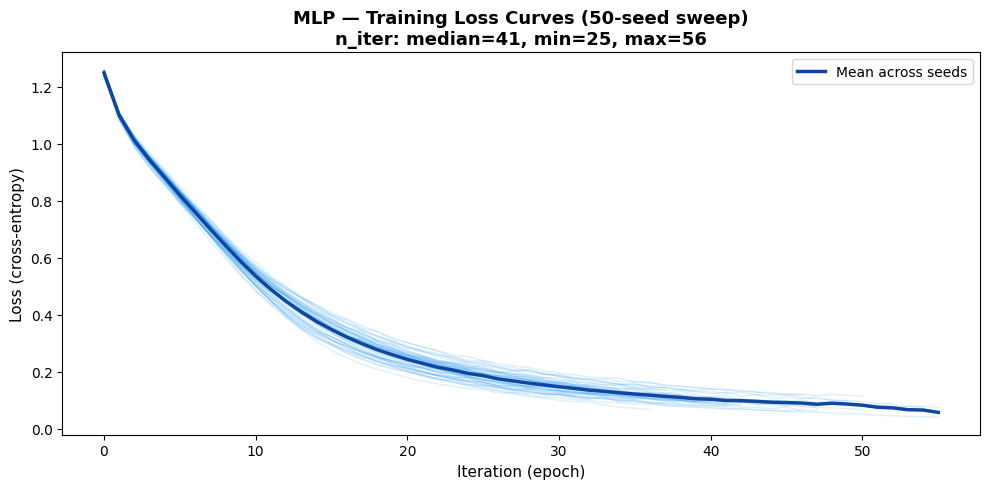

↑ Each thin curve = one fitted MLP's training loss across 50 random seeds.
  Bold curve = mean loss at each iteration (NaN-padded for early-stopped seeds).
  A tight bundle = consistent convergence across inits; a wide fan = init-sensitive.
  Title's n_iter (median/min/max) summarises early-stopping variability.


In [5]:
plot_sweep_loss_curves(sweep_mlp)

print("↑ Each thin curve = one fitted MLP's training loss across 50 random seeds.")
print("  Bold curve = mean loss at each iteration (NaN-padded for early-stopped seeds).")
print("  A tight bundle = consistent convergence across inits; a wide fan = init-sensitive.")
print("  Title's n_iter (median/min/max) summarises early-stopping variability.")

### DIAGNOSTIC PLOT 2: Architecture × Alpha Grid Search Heatmap

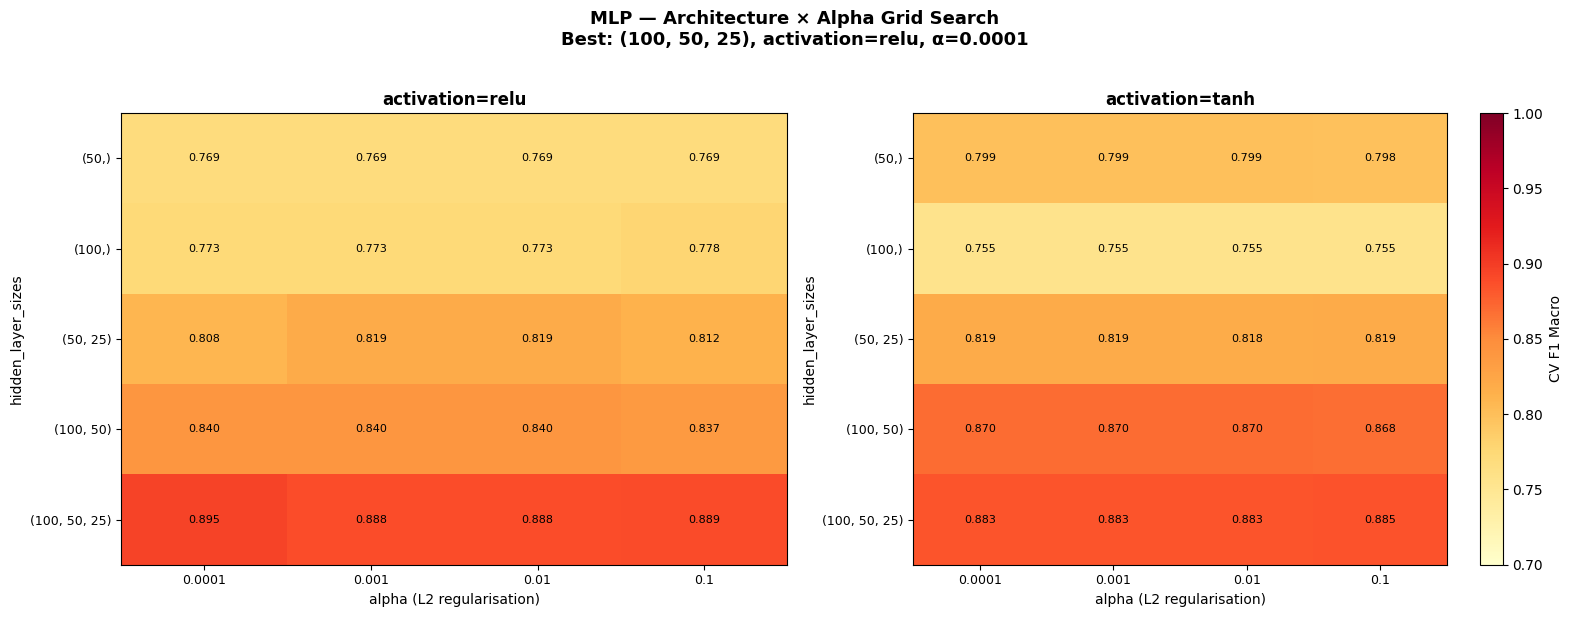

↑ Each cell = mean CV F1 macro across 5 folds for one (architecture, alpha, activation) combo.
  Deeper nets aren't always better — extra capacity overfits ~700 balanced samples.
  High alpha = stronger L2 — guards minority classes from being memorised.


In [6]:
results_df = pd.DataFrame(grid_mlp.cv_results_)
results_df["arch_str"] = results_df["param_hidden_layer_sizes"].apply(str)
arch_order = ["(50,)", "(100,)", "(50, 25)", "(100, 50)", "(100, 50, 25)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, act in zip(axes, ["relu", "tanh"]):
    sub = results_df[results_df["param_activation"] == act]
    pivot = sub.pivot_table(
        index="arch_str", columns="param_alpha", values="mean_test_score"
    ).reindex(arch_order)

    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0.7, vmax=1.0)
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([str(a) for a in sorted(pivot.columns)], fontsize=9)
    ax.set_yticks(range(len(arch_order)))
    ax.set_yticklabels(arch_order, fontsize=9)
    ax.set_xlabel("alpha (L2 regularisation)", fontsize=10)
    ax.set_ylabel("hidden_layer_sizes", fontsize=10)
    ax.set_title(f"activation={act}", fontsize=12, fontweight="bold")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=8, color="black" if val < 0.9 else "white")

plt.colorbar(im, ax=axes[1], label="CV F1 Macro")
fig.suptitle(
    f"MLP — Architecture × Alpha Grid Search\n"
    f"Best: {grid_mlp.best_params_['hidden_layer_sizes']}, "
    f"activation={grid_mlp.best_params_['activation']}, α={grid_mlp.best_params_['alpha']}",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
save_plot("mlp_hyperparameter_heatmap")
plt.show()

print("↑ Each cell = mean CV F1 macro across 5 folds for one (architecture, alpha, activation) combo.")
print("  Deeper nets aren't always better — extra capacity overfits ~700 balanced samples.")
print("  High alpha = stronger L2 — guards minority classes from being memorised.")

### DIAGNOSTIC PLOT 3: Posterior Probability Distributions

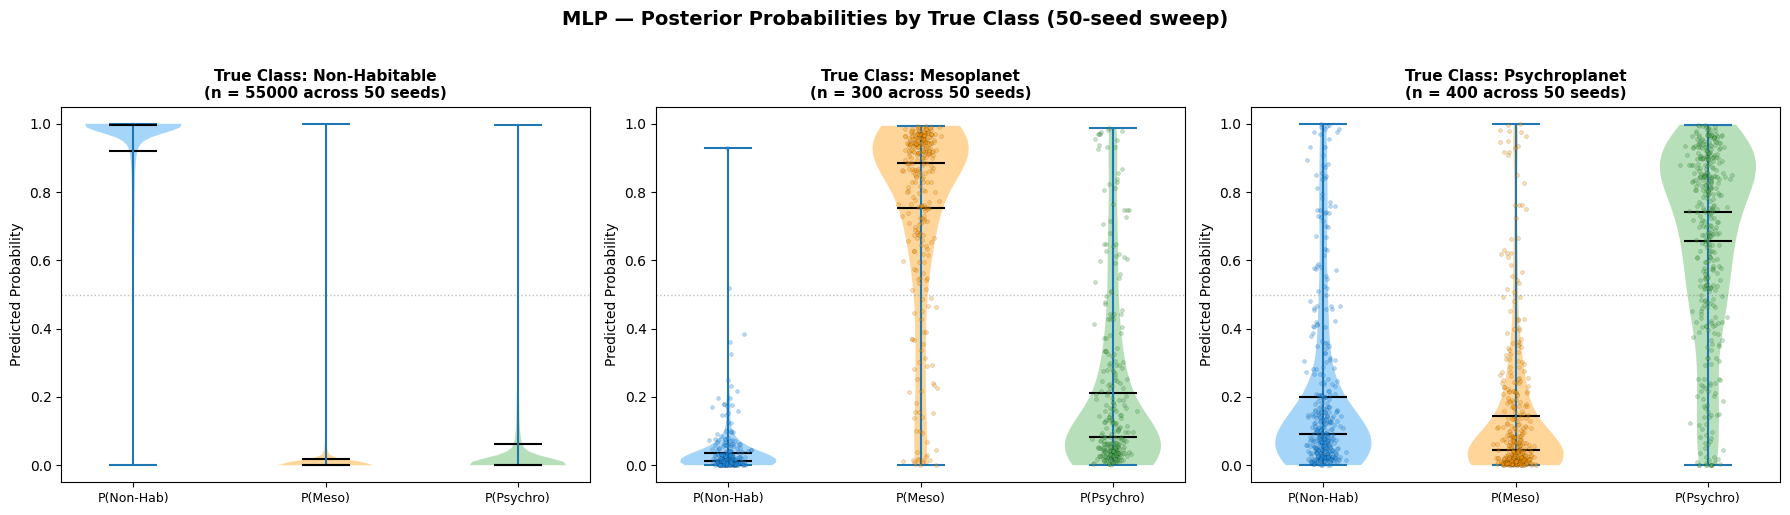

↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,
  aggregated across all 50 sweep seeds. With 6 mesoplanet × 50 splits = 300 probability points
  per minority-class panel, the violins now carry real statistical mass — unlike the single-split
  version where 6–8 samples produced uninformative shapes.
  A well-calibrated MLP concentrates P(true class) near 1.0 across most splits.


In [7]:
plot_sweep_posterior_violins(sweep_mlp)

print("↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,")
print("  aggregated across all 50 sweep seeds. With 6 mesoplanet × 50 splits = 300 probability points")
print("  per minority-class panel, the violins now carry real statistical mass — unlike the single-split")
print("  version where 6–8 samples produced uninformative shapes.")
print("  A well-calibrated MLP concentrates P(true class) near 1.0 across most splits.")

## Metrics
### Classification Report + F1 Scores

MLP — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9713     0.0074     0.9559     0.9867
Mesoplanet           0.4159     0.1209     0.1290     0.7500
Psychroplanet        0.2054     0.0550     0.0909     0.3243
----------------------------------------------------------------
Macro avg            0.5309     0.0513     0.4074     0.6644
Weighted avg         0.9628     0.0080     0.9458     0.9796

5-Fold CV F1 Macro: 0.8811 ± 0.0457

MLP — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9989 ± 0.0010    0.9452 ± 0.0141
Mesoplanet       0.2831 ± 0.0989    0.8367 ± 0.1632
Psychroplanet    0.1196 ± 0.0349    0.7650 ± 0.1687
----------------------------------------------------------------
Macro avg        0.4672 ± 0.0388    0.8490 ± 0.0713
Wei

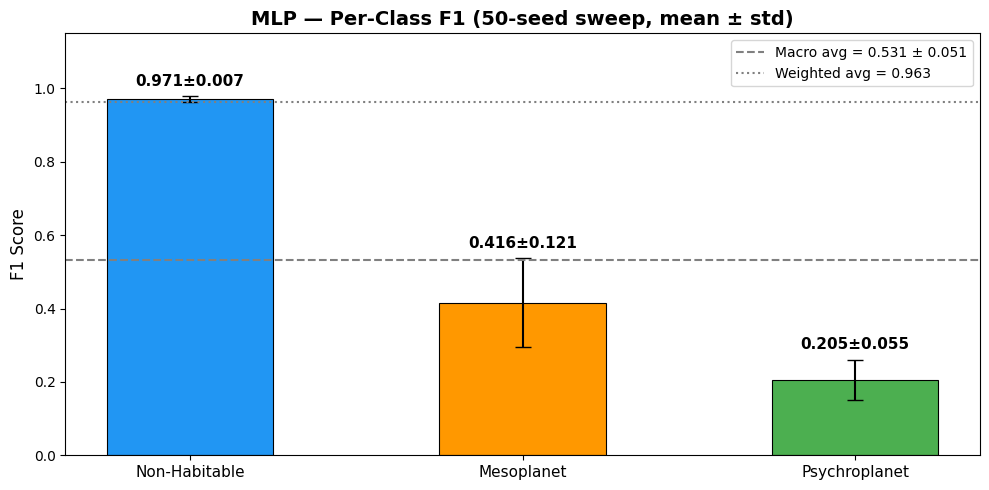

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_mlp)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_mlp = run_stratified_cv(mlp, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_mlp)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_mlp)

### Confusion Matrix (Counts + Normalized)

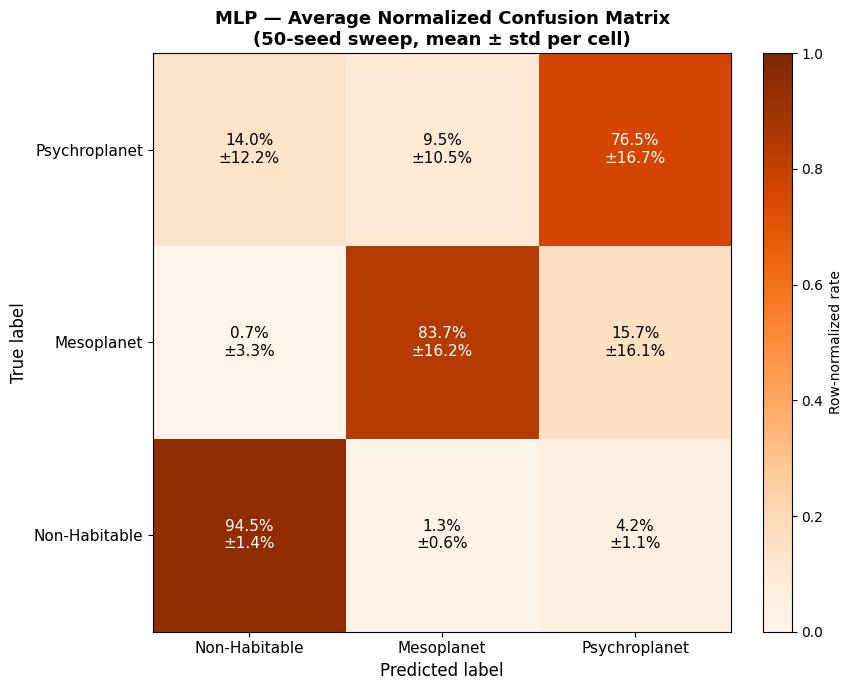

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 13.76 ± 6.57 per split  (1.3% ± 0.6% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 46.50 ± 12.38 per split  (4.2% ± 1.1% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.04 ± 0.20 per split  (0.7% ± 3.3% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 0.94 ± 0.97 per split  (15.7% ± 16.1% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 1.12 ± 0.97 per split  (14.0% ± 12.2% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 0.76 ± 0.84 per split  (9.5% ± 10.5% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_mlp)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_mlp)

## Interpretation:
